Total rows: 220
Species x Color found in CSV:
species  color
cat      black     38
         gray      16
dog      brown    142
         white     24

Subgroups to evaluate: ['cat_black', 'cat_gray', 'dog_brown', 'dog_white']

Plot colors assigned:
  cat    / black    → #1a1a1a
  cat    / gray     → #5c5c5c
  dog    / brown    → #c8a882
  dog    / white    → #d9d9d9
Loading TransUNet pretrained weights from /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/TransUNet/model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz
load_pretrained: grid-size from 14 to 16

#################################################################
  Evaluating seed 22
#################################################################
  Cat/Black           Dice=0.9667  IoU=0.9355
  Cat/Gray            Dice=0.8969  IoU=0.8169
  Dog/Brown           Dice=0.9449  IoU=0.8964
  Dog/White           Dice=0.9555  IoU=0.9150

#################################################################
  Evaluating seed 42
########

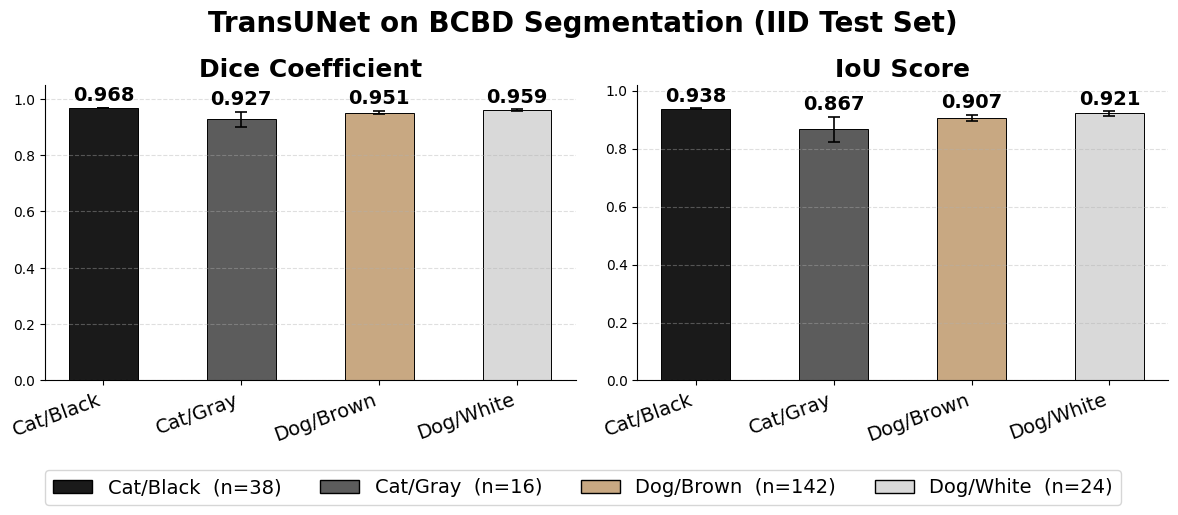

Plot saved → test_subgroup_accuracy.png


In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.optim as optim
from transunet_model import build_transunet, DEFAULT_PRETRAINED

# ── Config ────────────────────────────────────────────────────────────────────
ALL_TEST_CSV = "/home/ahsan/test-project/ISIC-2019/Pet_data/pet_fixed_by_label/Metadata/Metadata_final/Cat_black_grey_Dog_brown_white_test_IID.csv"
PET_DATA_ROOT = "/home/ahsan/test-project/ISIC-2019/Pet_data/pet_fixed_by_label"
LR_INITIAL = 1e-4
SPECIES_TO_CLASS = {"background": 0, "cat": 1, "dog": 2}
NUM_CLASSES      = 3
BATCH_SIZE       = 8
VIT_NAME = "R50-ViT-B_16"
N_SKIP = 3
DEVICE           = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 265
PRETRAINED_PATH = str(DEFAULT_PRETRAINED)
SEEDS = [22, 42, 123]
EPOCHS = 100
CHECKPOINT_DIR = "/home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/TransUNet/pets_checkpoints/multiseed"
# Exactly the 4 subgroups you want
SUBGROUPS = [
    {"species": "cat", "color": "black"},
    {"species": "cat", "color": "gray"},
    {"species": "dog", "color": "brown"},
    {"species": "dog", "color": "white"},
]

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ── Load CSV 
df_all = pd.read_csv(ALL_TEST_CSV)
df_all.columns    = df_all.columns.str.strip()
df_all["species"] = df_all["species"].str.lower().str.strip()
df_all["color"]   = df_all["color"].str.lower().str.strip()

print(f"Total rows: {len(df_all)}")
print(f"Species x Color found in CSV:")
print(df_all.groupby(["species", "color"]).size().to_string())

# ── Build SUBGROUPS dynamically from whatever is in the CSV 
SUBGROUPS = [
    {"species": sp, "color": col}
    for (sp, col) in df_all.groupby(["species", "color"]).groups.keys()
]
subgroup_names = [f"{s['species']}_{s['color']}" for s in SUBGROUPS]
print(f"\nSubgroups to evaluate: {subgroup_names}")


# ── Build PLOT_COLOR dynamically 
# Consistent palette: black / grey / white + light brown for brown subgroups
COLOR_MAP = {
    "black" : "#1a1a1a",
    "grey"  : "#5c5c5c",
    "gray"  : "#5c5c5c",
    "white" : "#d9d9d9",
    "brown" : "#c8a882",
    "other" : "#bdbdbd",
}
GRAYSCALE_FALLBACK = ["#1a1a1a", "#5c5c5c", "#d9d9d9", "#c8a882", "#bdbdbd"]

PLOT_COLOR = {}
for i, sg in enumerate(SUBGROUPS):
    key = (sg["species"], sg["color"])
    PLOT_COLOR[key] = COLOR_MAP.get(sg["color"], GRAYSCALE_FALLBACK[i % len(GRAYSCALE_FALLBACK)])

print(f"\nPlot colors assigned:")
for k, v in PLOT_COLOR.items():
    print(f"  {k[0]:6s} / {k[1]:8s} → {v}")

# ── Dataset 
class PetSubgroupDataset(Dataset):
    def __init__(self, sub_df, data_root, transform=None):
        self.df        = sub_df.reset_index(drop=True)
        self.data_root = data_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        img_path  = os.path.join(self.data_root, row["image"])
        mask_path = os.path.join(self.data_root, row["mask"])
        species   = str(row["species"]).lower().strip()

        image       = np.array(Image.open(img_path).convert("RGB"))
        binary_mask = np.array(Image.open(mask_path).convert("L")) > 127
        species_cls = SPECIES_TO_CLASS[species]
        mask        = np.zeros(binary_mask.shape, dtype=np.int64)
        mask[binary_mask] = species_cls

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask  = aug["mask"]

        if not isinstance(mask, torch.Tensor):
            mask = torch.as_tensor(mask)
        if mask.ndim == 3:
            mask = mask.squeeze(0)
        if mask.is_floating_point():
            mask = mask.round()

        return image, mask.long()

# ── Metrics 
def compute_metrics(outputs, masks, num_classes, smooth=1e-6):
    """
    outputs : [B, C, H, W] raw logits
    masks   : [B, H, W]    long ground truth
    """
    preds = outputs.argmax(dim=1) # [B, H, W]

    acc = (preds == masks).float().mean().item()

    preds_flat = preds.view(-1)   # [B * H * W]
    masks_flat = masks.view(-1)   # [B * H * W]

    preds_one_hot = F.one_hot(preds_flat, num_classes=num_classes).float()
    masks_one_hot = F.one_hot(masks_flat, num_classes=num_classes).float()

    inter = (preds_one_hot * masks_one_hot).sum(dim=0)
    total_preds = preds_one_hot.sum(dim=0)
    total_masks = masks_one_hot.sum(dim=0)
    union = total_preds + total_masks - inter

    inter = inter[1:]
    union = union[1:]
    total_preds = total_preds[1:]
    total_masks = total_masks[1:]

    class_present = (total_masks > 0)

    if class_present.sum() == 0:
        # Avoid division by zero if no foreground classes exist in the batch
        return {"acc": acc, "dice": 0.0, "iou": 0.0}

    dice_per_class = (2 * inter + smooth) / (total_preds + total_masks + smooth)
    iou_per_class = (inter + smooth) / (union + smooth)

    mean_dice = dice_per_class[class_present].mean().item()
    mean_iou = iou_per_class[class_present].mean().item()

    return {
        "acc"  : acc,
        "dice" : mean_dice,
        "iou"  : mean_iou,
    }

def evaluate_loader(model, loader):
    tot_acc = tot_dice = tot_iou = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            m = compute_metrics(outputs, masks, NUM_CLASSES)
            tot_acc  += m["acc"]
            tot_dice += m["dice"]
            tot_iou  += m["iou"]
    n_batches = len(loader)
    if n_batches == 0:
        return {"acc": 0.0, "dice": 0.0, "iou": 0.0}
    return {
        "acc"  : tot_acc  / n_batches,
        "dice" : tot_dice / n_batches,
        "iou"  : tot_iou  / n_batches,
    }

# ── Build subgroup loaders (once)
subgroup_loaders = {}
for sg in SUBGROUPS:
    species = sg["species"]
    color   = sg["color"]
    key     = f"{species}_{color}"
    label   = f"{species.capitalize()}/{color.capitalize()}"
    sub_df  = df_all[(df_all["species"] == species) & (df_all["color"] == color)]
    dataset = PetSubgroupDataset(sub_df, PET_DATA_ROOT, transform=val_transform)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True)
    subgroup_loaders[key] = {
        "loader"  : loader,
        "label"   : label,
        "species" : species,
        "color"   : color,
        "n"       : len(sub_df),
    }

model = build_transunet(
    num_classes     = NUM_CLASSES,
    img_size        = IMG_SIZE,
    vit_name        = VIT_NAME,
    n_skip          = N_SKIP,
    pretrained_path = PRETRAINED_PATH,
    device          = DEVICE,
)
model.to(DEVICE)

# ── Multi-seed evaluation 
per_seed_results = []
for seed in SEEDS:
    ckpt = f"{CHECKPOINT_DIR}/TransUNet_Pets_multiclass_seed{seed}_epoch{EPOCHS}.pth"
    if not os.path.exists(ckpt):
        print(f"Skipping seed {seed}: {ckpt} not found")
        continue
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    print(f"\n{'#'*65}\n  Evaluating seed {seed}\n{'#'*65}")
    seed_results = {}
    for key, info in subgroup_loaders.items():
        m = evaluate_loader(model, info["loader"])
        seed_results[key] = m
        print(f"  {info['label']:<18}  Dice={m['dice']:.4f}  IoU={m['iou']:.4f}")
    per_seed_results.append(seed_results)

results = {}
for key, info in subgroup_loaders.items():
    dice_vals = [sr[key]["dice"] for sr in per_seed_results if key in sr]
    iou_vals  = [sr[key]["iou"]  for sr in per_seed_results if key in sr]
    results[key] = {
        "label"     : info["label"],
        "species"   : info["species"],
        "color"     : info["color"],
        "n"         : info["n"],
        "dice"      : float(np.mean(dice_vals)) if dice_vals else 0.0,
        "dice_std"  : float(np.std(dice_vals, ddof=1)) if len(dice_vals) > 1 else 0.0,
        "iou"       : float(np.mean(iou_vals))  if iou_vals  else 0.0,
        "iou_std"   : float(np.std(iou_vals, ddof=1)) if len(iou_vals) > 1 else 0.0,
    }

# ── Console table (mean ± std) 
print("\n" + "="*65)
print(f"{'Subgroup':<18} {'N':>5} {'Dice':>22} {'IoU':>22}")
print("="*65)
for key, m in results.items():
    print(f"{m['label']:<18} {m['n']:>5} "
          f"{m['dice']:.4f} ± {m['dice_std']:.4f}   "
          f"{m['iou']:.4f} ± {m['iou_std']:.4f}")
print("="*65)

# ── Plot 
keys       = list(results.keys())
labels     = [results[k]["label"] for k in keys]
bar_colors = [PLOT_COLOR[(results[k]["species"], results[k]["color"])] for k in keys]
x          = np.arange(len(keys))

metrics_cfg = [
    ("dice", "Dice Coefficient"),
    ("iou",  "IoU Score"),
]

fig, axes = plt.subplots(1, 2, figsize=(max(12, len(keys) * 2.5), 5))
fig.suptitle("TransUNet on BCBD Segmentation (IID Test Set)", fontsize=20, fontweight='bold')

for ax, (metric, title) in zip(axes, metrics_cfg):
    values = [results[k][metric] for k in keys]
    stds   = [results[k][f"{metric}_std"] for k in keys]
    bars   = ax.bar(
        x, values, yerr=stds, capsize=4,
        color=bar_colors, edgecolor='black', linewidth=0.7, width=0.5,
        error_kw=dict(elinewidth=1.2, capthick=1.2, ecolor='black'),
    )

    ymax = max((v + s for v, s in zip(values, stds)), default=1.0)
    ax.set_ylim(0, min(1.25, ymax + 0.08))
    label_offset = 0.01

    for bar, val, std in zip(bars, values, stds):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + label_offset,
            f"{val:.3f}",
            ha='center', va='bottom', fontsize=14, fontweight='bold'
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=14)
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend with sample counts
legend_handles = [
    mpatches.Patch(
        facecolor=PLOT_COLOR[(results[k]["species"], results[k]["color"])],
        edgecolor='black',
        label=f"{results[k]['label']}  (n={results[k]['n']})"
    )
    for k in keys
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=min(len(keys), 5),          # max 5 per row
    bbox_to_anchor=(0.5, -0.03),
    fontsize=14, frameon=True
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("test_subgroup_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → test_subgroup_accuracy.png")

In [ ]:
"""transunet"""
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
Cat/Black             38     0.9715   0.9667   0.9355   0.0211
Cat/Gray              16     0.9134   0.8969   0.8169   0.0486
Dog/Brown            142     0.9595   0.9449   0.8964   0.0322
Dog/White             24     0.9658   0.9555   0.9150   0.0265
=================================================================
""" OOD """
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
Cat/Brown            266     0.5553   0.0995   0.0622   0.3158
Cat/White             66     0.5529   0.0888   0.0515   0.3195
Dog/Black            589     0.6577   0.2853   0.1994   0.2516
Dog/Gray               8     0.6243   0.4400   0.2820   0.2005
=================================================================
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
Cat/Brown            266     0.5665   0.1490   0.0915   0.3002
Cat/White             66     0.5538   0.1052   0.0656   0.3134
Dog/Black            589     0.6304   0.1956   0.1324   0.2819
Dog/Gray               8     0.4876   0.0346   0.0176   0.3403
=================================================================
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
Cat/Brown            266     0.6704   0.4292   0.3114   0.2044
Cat/White             66     0.5684   0.1521   0.0946   0.2961
Dog/Black            589     0.6907   0.3750   0.2784   0.2188
Dog/Gray               8     0.6370   0.4749   0.3114   0.1893
=================================================================

'transunet'

In [ ]:
""" Latest Results: Test-OOD UNet_Cat_black_grey_Dog_brown_white_epoch100.pth """
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
Cat/Brown            266     0.5374   0.0490   0.0270   0.3317
Cat/White             66     0.5293   0.0477   0.0259   0.3351
Dog/Black            589     0.7186   0.4595   0.3412   0.1928
Dog/Gray               8     0.6345   0.4582   0.2971   0.1981
=================================================================
""" IID """
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
Cat/Black             38     0.9704   0.9652   0.9330   0.0207
Cat/Gray              16     0.9452   0.9363   0.8809   0.0331
Dog/Brown            142     0.9644   0.9519   0.9084   0.0266
Dog/White             24     0.9650   0.9545   0.9131   0.0253
=================================================================
""" multi-seed#1: OOD """
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
Cat/Brown            266     0.5384   0.0406   0.0222   0.3356
Cat/White             66     0.5209   0.0028   0.0014   0.3527
Dog/Black            589     0.7542   0.5444   0.4188   0.1638
Dog/Gray               8     0.6443   0.4766   0.3129   0.1953
""" multi-seed#2: OOD """
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
Cat/Brown            266     0.5421   0.0604   0.0337   0.3290
Cat/White             66     0.5281   0.0016   0.0008   0.3486
Dog/Black            589     0.7361   0.5026   0.3778   0.1776
Dog/Gray               8     0.6129   0.3944   0.2457   0.2225
=================================================================
""" multi-seed#3: OOD """
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
Cat/Brown            266     0.5569   0.1162   0.0657   0.3097
Cat/White             66     0.5296   0.0283   0.0147   0.3440
Dog/Black            589     0.7085   0.4175   0.3018   0.2068
Dog/Gray               8     0.7320   0.6433   0.4741   0.1385
=================================================================
""" Mean & Std. """
=================================================================
Subgroup      Dice (mean ±)     mIoU (mean ±)
Cat/Brown     0.0624 ± 0.0382     0.0405 ± 0.0220
Cat/White     0.0109 ± 0.0139     0.0056 ± 0.0072
Dog/Black     0.4882 ± 0.0517     0.3661 ± 0.0586
Dog/Gray      0.5048 ± 0.1078     0.3442 ± 0.1145

In [20]:
"""
UNet Segmentation Evaluation — Confusion Matrix & Error Metrics
Dataset: Cats & Dogs (3-class: Background, Cats, Dogs)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import os
import itertools
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ─────────────────────────────────────────────
# 1.  CLASS DEFINITIONS model, ISIC_TEST_CSV, IMAGE_DIR, MASK_DIR
# ─────────────────────────────────────────────
CLASSES      = ["BG", "Cats", "Dogs"]
NUM_CLASSES  = len(CLASSES)
DEVICE       = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

# ─────────────────────────────────────────────
# 4.  EVALUATION LOOP
# ─────────────────────────────────────────────
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)                        # [B, C, H, W]
            preds  = logits.argmax(dim=1)               # [B, H, W]
            all_preds.append(preds.cpu().numpy().flatten())
            all_targets.append(masks.cpu().numpy().flatten())
    return np.concatenate(all_preds), np.concatenate(all_targets)

# ─────────────────────────────────────────────
# 5.  METRICS
# ─────────────────────────────────────────────
def compute_metrics(y_true, y_pred, classes):
    label_ids = list(range(len(classes)))
    cm = confusion_matrix(y_true, y_pred, labels=label_ids)
    report = classification_report(
        y_true, y_pred, labels=label_ids, target_names=classes, output_dict=True, zero_division=0
    )

    # Per-class IoU  (Intersection over Union)
    iou = {}
    for i, cls in enumerate(classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        denom = tp + fp + fn
        iou[cls] = tp / denom if denom > 0 else 0.0

    # Pixel accuracy
    pixel_acc = np.diag(cm).sum() / cm.sum()
    mean_iou  = np.mean(list(iou.values()))
    return cm, report, iou, pixel_acc, mean_iou

# ─────────────────────────────────────────────
# 6.  VISUALISATION
# ─────────────────────────────────────────────
def plot_confusion_matrix(cm, classes, pixel_acc, mean_iou, iou, report):
    # Publication-style palette (print-friendly, white background)
    CLASS_COLORS = {
        "BG": "#7f7f7f",   # gray
        "Cats":       "#d62728",   # red  (matches mask viz)
        "Dogs":       "#1f77b4",   # blue (matches mask viz)
    }
    cmap = plt.cm.Blues

    fig = plt.figure(figsize=(18, 14), facecolor="white")
    fig.suptitle(
        "UNet Segmentation — Evaluation Dashboard\nCats & Dogs Dataset",
        color="black", fontsize=18, fontweight="bold", y=0.98,
    )

    gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.4,
                          left=0.07, right=0.97, top=0.92, bottom=0.06)
    ax_cm      = fig.add_subplot(gs[0, :2])
    ax_norm    = fig.add_subplot(gs[1, :2])
    ax_bar     = fig.add_subplot(gs[0, 2])
    ax_metrics = fig.add_subplot(gs[1, 2])

    def style_ax(ax, title):
        ax.set_facecolor("white")
        ax.tick_params(colors="black")
        for sp in ax.spines.values():
            sp.set_edgecolor("#cccccc")
        ax.title.set_color("black")
        ax.title.set_fontsize(18)
        ax.set_title(title, fontweight="bold")
        ax.xaxis.label.set_color("black")
        ax.yaxis.label.set_color("black")

    # ─── RAW confusion matrix ───────────────────
    im1 = ax_cm.imshow(cm, cmap=cmap, aspect="auto")
    ax_cm.set_xticks(range(len(classes)))
    ax_cm.set_yticks(range(len(classes)))
    ax_cm.set_xticklabels(classes, color="black", fontsize=16)
    ax_cm.set_yticklabels(classes, color="black", fontsize=16)
    ax_cm.set_xlabel("Predicted Label", fontsize=16)
    ax_cm.set_ylabel("True Label", fontsize=16)
    cb1 = fig.colorbar(im1, ax=ax_cm, fraction=0.046, pad=0.04)
    cb1.ax.tick_params(colors="black")
    max_val = cm.max()
    for i, j in itertools.product(range(len(classes)), range(len(classes))):
        color = "white" if cm[i, j] > max_val * 0.55 else "black"
        label = "TP" if i == j else "FP/FN"
        ax_cm.text(
            j, i, f"{cm[i, j]:,}\n({label})",
            ha="center", va="center", color=color, fontsize=20, fontweight="bold",
        )
    style_ax(ax_cm, "Raw Confusion Matrix (Pixel Counts)")

    # ─── NORMALISED confusion matrix ────────────
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im2 = ax_norm.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect="auto")
    ax_norm.set_xticks(range(len(classes)))
    ax_norm.set_yticks(range(len(classes)))
    ax_norm.set_xticklabels(classes, color="black", fontsize=16)
    ax_norm.set_yticklabels(classes, color="black", fontsize=16)
    ax_norm.set_xlabel("Predicted Label", fontsize=16)
    ax_norm.set_ylabel("True Label", fontsize=16)
    cb2 = fig.colorbar(im2, ax=ax_norm, fraction=0.046, pad=0.04)
    cb2.ax.tick_params(colors="black")
    for i, j in itertools.product(range(len(classes)), range(len(classes))):
        color = "white" if cm_norm[i, j] > 0.55 else "black"
        ax_norm.text(
            j, i, f"{cm_norm[i, j]:.2%}",
            ha="center", va="center", color=color, fontsize=20, fontweight="bold",
        )
    style_ax(ax_norm, "UNet on BCBD Segmentation (OOD Test Set)")

    # ─── IoU BAR CHART ──────────────────────────
    colors_bar = [CLASS_COLORS.get(c, "#4c72b0") for c in classes]
    iou_vals   = [iou[c] for c in classes]
    bars = ax_bar.barh(classes, iou_vals, color=colors_bar, edgecolor="black", height=0.55, linewidth=0.8)
    ax_bar.set_xlim(0, 1.05)
    ax_bar.axvline(
        mean_iou, color="#2ca02c", linestyle="--", linewidth=1.5,
        label=f"mIoU = {mean_iou:.3f}",
    )
    ax_bar.legend(frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=12)
    for bar, v in zip(bars, iou_vals):
        ax_bar.text(
            v + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{v:.3f}", va="center", color="black", fontsize=12,
        )
    ax_bar.set_xlabel("IoU Score", fontsize=14)
    ax_bar.grid(axis="x", linestyle=":", alpha=0.4)
    style_ax(ax_bar, "Per-Class IoU")

    # ─── METRICS TABLE ──────────────────────────
    ax_metrics.axis("off")
    style_ax(ax_metrics, "Classification Metrics")
    headers = ["Class", "Precision", "Recall", "F1"]
    rows = []
    for cls in classes:
        r = report[cls]
        rows.append([cls, f"{r['precision']:.3f}", f"{r['recall']:.3f}", f"{r['f1-score']:.3f}"])
    rows.append(["—" * 10] * 4)
    rows.append(["Pixel Acc", f"{pixel_acc:.4f}", "", ""])
    rows.append(["Mean IoU", f"{mean_iou:.4f}", "", ""])

    table = ax_metrics.table(
        cellText=rows, colLabels=headers,
        cellLoc="center", loc="center",
        bbox=[0.0, 0.05, 1.0, 0.88],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor("#cccccc")
        if r == 0:
            cell.set_facecolor("#e8e8e8")
            cell.set_text_props(color="black", fontweight="bold")
        elif rows[r - 1][0].startswith("—"):
            cell.set_facecolor("white")
            cell.set_text_props(color="#cccccc")
        elif rows[r - 1][0] in ("Pixel Acc", "Mean IoU"):
            cell.set_facecolor("#f5f5f5")
            cell.set_text_props(color="#1f77b4", fontweight="bold")
        else:
            cell.set_facecolor("white")
            cell.set_text_props(color="black")

    out_path = "/home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/BCBD_unet_eval_dashboard_IID.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close()
    print(f"\nDashboard saved → {out_path}")
    return out_path

# ─────────────────────────────────────────────
# 7.  MAIN
# ─────────────────────────────────────────────

print("=" * 58)
print("  UNet Segmentation Evaluation — Cats & Dogs")
print("=" * 58)



# ── Inference (full test set — not the last subgroup loader from cell 0)
full_dataset = PetSubgroupDataset(df_all, PET_DATA_ROOT, transform=val_transform)
full_loader = DataLoader(
    full_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)
print(f"\n⏳  Running inference on full test set ({len(df_all)} images)…")
y_pred, y_true = evaluate(model, full_loader, DEVICE)

# ── Metrics
cm, report, iou, pixel_acc, mean_iou = compute_metrics(y_true, y_pred, CLASSES)

print("\n── Confusion Matrix ──────────────────────────────")
print(f"  Rows = True label  |  Cols = Predicted label")
print(f"  Classes: {CLASSES}\n")
print(cm)
print("\n── Per-class Metrics ─────────────────────────────")
print(classification_report(y_true, y_pred, labels=list(range(len(CLASSES))), target_names=CLASSES, zero_division=0))
print("── Summary ───────────────────────────────────────")
for cls in CLASSES:
    print(f"  IoU [{cls:12s}]: {iou[cls]:.4f}")
print(f"  Mean IoU         : {mean_iou:.4f}")
print(f"  Pixel Accuracy   : {pixel_acc:.4f}")

# ── Plot
print("\n📊  Generating dashboard…")
plot_confusion_matrix(cm, CLASSES, pixel_acc, mean_iou, iou, report)




  UNet Segmentation Evaluation — Cats & Dogs

⏳  Running inference on full test set (220 images)…



── Confusion Matrix ──────────────────────────────
  Rows = True label  |  Cols = Predicted label
  Classes: ['BG', 'Cats', 'Dogs']

[[8581500   58288  188232]
 [  43125 1469534   17309]
 [ 144509    4824 3910599]]

── Per-class Metrics ─────────────────────────────
              precision    recall  f1-score   support

          BG       0.98      0.97      0.98   8828020
        Cats       0.96      0.96      0.96   1529968
        Dogs       0.95      0.96      0.96   4059932

    accuracy                           0.97  14417920
   macro avg       0.96      0.97      0.96  14417920
weighted avg       0.97      0.97      0.97  14417920

── Summary ───────────────────────────────────────
  IoU [BG          ]: 0.9518
  IoU [Cats        ]: 0.9224
  IoU [Dogs        ]: 0.9168
  Mean IoU         : 0.9304
  Pixel Accuracy   : 0.9684

📊  Generating dashboard…

Dashboard saved → /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/BCBD_unet_eval_dashboard_IID.png


'/home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/BCBD_unet_eval_dashboard_IID.png'

In [ ]:
""" Baseline - Test-all ID """ UNet_Pet_Seg_multiclass_other_epoch100.pth
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
170Cat/Black---          38     0.9695   0.9659   0.9340   0.0204
6  Cat/Brown              3     0.9601   0.9508   0.9062   0.0278
43 Cat/Gray              16     0.9069   0.8881   0.7998   0.0535
111Cat/Other---          25     0.9066   0.7033   0.6368   0.1237
2 Cat/White              1     0.8843   0.9082   0.8318   0.0828
4 Dog/Black              1     0.5937   0.0000   0.0000   0.3413
579Dog/Brown---         142     0.9600   0.9459   0.8976   0.0288
178Dog/Other---          40     0.9137   0.8983   0.8165   0.0548
65 Dog/White             24     0.9596   0.9479   0.9013   0.0283
=================================================================
""" Baseline - Test-all ID """ UNet_Pet_Seg_multiclass_All_epoch100.pth
=================================================================
Cat/Black             38     0.9666   0.9606   0.9247   0.0229
Cat/Brown              3     0.9595   0.9503   0.9053   0.0280
Cat/Gray              16     0.9468   0.9393   0.8858   0.0360
Cat/Other             25     0.9301   0.9150   0.8470   0.0522
Cat/White              1     0.9393   0.9482   0.9016   0.0418
Dog/Black              1     0.5891   0.0000   0.0000   0.3434
Dog/Brown            142     0.9550   0.9367   0.8824   0.0321
Dog/Other             40     0.9096   0.8974   0.8147   0.0563
Dog/White             24     0.9481   0.9393   0.8856   0.0319
=================================================================
""" Test-all OOD """ UNet_Pet_Seg_multiclass_other_epoch100.pth
=================================================================
Cat/Black---           1     0.9825   0.9721   0.9458   0.0139
Cat/Brown            266     0.8431   0.8088   0.7028   0.0793
Cat/Gray              29     0.9481   0.9382   0.8839   0.0333
Cat/Other---         139     0.8856   0.8253   0.7319   0.0737
Cat/White             66     0.7667   0.6807   0.5378   0.1327
Dog/Black            589     0.7341   0.4896   0.3716   0.1817
Dog/Brown---          96     0.9047   0.8673   0.7767   0.0564
Dog/Gray               8     0.7701   0.7167   0.5585   0.1150
Dog/Other---         178     0.8290   0.7304   0.6080   0.1074
Dog/White              9     0.9290   0.9086   0.8364   0.0445
=================================================================
""" Test-all OOD """ UNet_Pet_Seg_multiclass_All_epoch100.pth
=================================================================
Cat/Black              1     0.9815   0.9708   0.9433   0.0142
Cat/Brown            266     0.8517   0.8227   0.7236   0.0755
Cat/Gray              29     0.9510   0.9409   0.8887   0.0342
Cat/Other            139     0.8976   0.8513   0.7636   0.0659
Cat/White             66     0.8012   0.7504   0.6100   0.1080
Dog/Black            589     0.6785   0.3488   0.2429   0.2289
Dog/Brown             96     0.8577   0.7956   0.6677   0.0804
Dog/Gray               8     0.5834   0.3351   0.2013   0.2371
Dog/Other            178     0.8208   0.7138   0.5998   0.1129
Dog/White              9     0.9233   0.9094   0.8347   0.0439
=================================================================
""" Baseline ID-Testing """ UNet_Pet_Seg_multiclass_epoch100.pth
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
Cat/Black-             38     0.9606   0.9527   0.9102   0.0272
Cat/Brown              3     0.9105   0.8783   0.7830   0.0525
Cat/Gray-              16     0.9253   0.9137   0.8415   0.0505
Cat/Other             25     0.7595   0.4768   0.3556   0.2037
Cat/White              1     0.6154   0.5058   0.3385   0.2140
Dog/Black              1     0.6158   0.0258   0.0131   0.3340
Dog/Brown-            142     0.9551   0.9402   0.8882   0.0320
Dog/Other             40     0.9006   0.8795   0.7891   0.0675
Dog/White-             24     0.9652   0.9545   0.9131   0.0247
=================================================================
""" Test-all OOD """
=================================================================
Cat/Black-              1     0.9827   0.9720   0.9455   0.0137
Cat/Brown            266     0.5845   0.2069   0.1276   0.2817
Cat/Gray-              29     0.8465   0.7921   0.6653   0.0860
Cat/Other            139     0.5988   0.1868   0.1104   0.2911
Cat/White             66     0.5451   0.1163   0.0670   0.3209
Dog/Black            589     0.6535   0.2324   0.1608   0.2693
Dog/Brown-             96     0.8905   0.8408   0.7405   0.0647
Dog/Gray               8     0.6486   0.5021   0.3352   0.1886
Dog/Other            178     0.8427   0.7510   0.6280   0.1037
Dog/White-              9     0.6425   0.4250   0.3696   0.2119
=================================================================
""" Baseline ID-Testing """ UNet_Cat_brown_gray_Dog_black_white_epoch100
=================================================================
Cat/Black             38     0.9621   0.9553   0.9145   0.0273
Cat/Brown-              3     0.9474   0.9434   0.8929   0.0354
Cat/Gray-              16     0.9360   0.9263   0.8630   0.0413
Cat/Other             25     0.8726   0.8592   0.7546   0.0795
Cat/White              1     0.8665   0.8725   0.7738   0.0902
Dog/Black-              1     0.6392   0.2848   0.1661   0.2659
Dog/Brown            142     0.9313   0.9033   0.8278   0.0487
Dog/Other             40     0.9045   0.8859   0.7958   0.0642
Dog/White-             24     0.9567   0.9450   0.8958   0.0312
=================================================================
""" Test-all OOD """
=================================================================
Cat/Black              1     0.9801   0.9683   0.9385   0.0169
Cat/Brown            266     0.7617   0.6895   0.5667   0.1234
Cat/Gray              29     0.8637   0.8226   0.7099   0.0744
Cat/Other            139     0.7357   0.5622   0.4321   0.1661
Cat/White             66     0.5565   0.2043   0.1203   0.2922
Dog/Black            589     0.7068   0.4476   0.3113   0.1995
Dog/Brown             96     0.8350   0.7569   0.6207   0.0990
Dog/Gray               8     0.7125   0.6321   0.4621   0.1446
Dog/Other            178     0.8355   0.7551   0.6278   0.1047
Dog/White              9     0.9335   0.9256   0.8620   0.0404


In [ ]:
""" Baseline ID-Testing """ UNet_Pet_Seg_multiclass_epoch100.pth
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
Cat/Black             38     0.9670   0.9618   0.9277   0.0234
Cat/Gray              16     0.9430   0.9236   0.8667   0.0383
Dog/Brown            142     0.9648   0.9490   0.9039   0.0279
Dog/White             24     0.9667   0.9541   0.9126   0.0257
=================================================================
""" OOD-Testing """
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
Cat/Black              1     0.9829   0.9730   0.9475   0.0138
Cat/Gray              29     0.7068   0.4712   0.3834   0.1885
Dog/Brown             96     0.9501   0.9272   0.8740   0.0365
Dog/White              9     0.9490   0.9334   0.8756   0.0395
=================================================================
""" Color-shortcuts Testing """
=================================================================
Subgroup               N   Accuracy     Dice      IoU     Loss
=================================================================
Cat/Brown            266     0.5394   0.0124   0.0078   0.3443
Cat/White             66     0.5225   0.0036   0.0019   0.3502
Dog/Black            589     0.7618   0.5221   0.4276   0.1719
Dog/Gray               8     0.6888   0.5139   0.3789   0.1842
Dog/Other            178     0.9128   0.8634   0.7878   0.0628
=================================================================

Full test (929 images): 100%|██████████| 117/117 [00:09<00:00, 12.90it/s]


Confusion Matrix:
[[34307604   411747   588603]
 [  748571   168228  8888616]
 [  964603  8094928  6710044]]


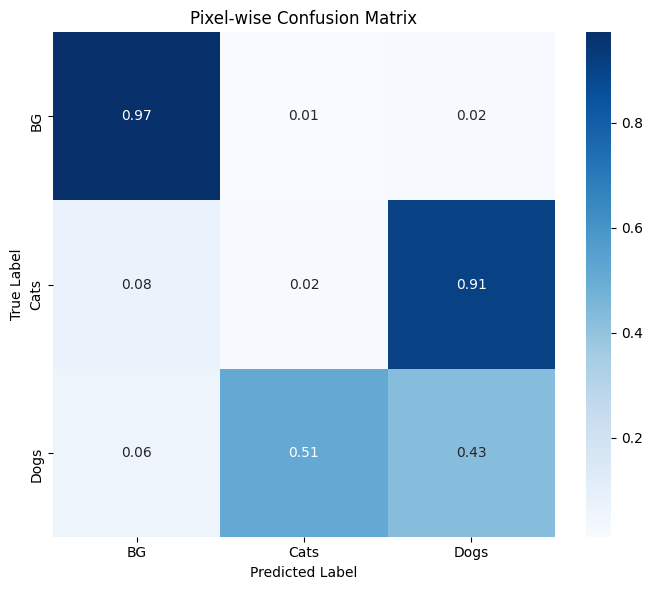


Class: BG
TP: 34307604
FP: 1713174
FN: 1000350
TN: 23861816
Dice Score : 0.9620
IoU        : 0.9267
Precision  : 0.9524
Recall     : 0.9717
Accuracy   : 0.9554

Class: Cats
TP: 168228
FP: 8506675
FN: 9637187
TN: 42570854
Dice Score : 0.0182
IoU        : 0.0092
Precision  : 0.0194
Recall     : 0.0172
Accuracy   : 0.7020

Class: Dogs
TP: 6710044
FP: 9477219
FN: 9059531
TN: 35636150
Dice Score : 0.4199
IoU        : 0.2658
Precision  : 0.4145
Recall     : 0.4255
Accuracy   : 0.6955


In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

# ---------------------------------------------------
# Configuration
# ---------------------------------------------------
NUM_CLASSES = 3
CLASS_NAMES = ["BG", "Cats", "Dogs"]
DEVICE = "cuda:1" if torch.cuda.is_available() else "cpu"

# ---------------------------------------------------
# Collect predictions and labels (full test set)
# ---------------------------------------------------
full_dataset = PetSubgroupDataset(df_all, PET_DATA_ROOT, transform=val_transform)
full_loader = DataLoader(
    full_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)

all_preds = []
all_targets = []

model.eval()

with torch.no_grad():

    for images, masks in tqdm(full_loader, total=len(full_loader), desc=f"Full test ({len(df_all)} images)"):

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        # Forward pass
        outputs = model(images)

        # Predicted labels
        preds = torch.argmax(outputs, dim=1)

        # Flatten for confusion matrix
        preds = preds.cpu().numpy().flatten()
        masks = masks.cpu().numpy().flatten()

        all_preds.extend(preds)
        all_targets.extend(masks)

# ---------------------------------------------------
# Compute confusion matrix
# ---------------------------------------------------
cm = confusion_matrix(
    all_targets,
    all_preds,
    labels=np.arange(NUM_CLASSES)
)

print("Confusion Matrix:")
print(cm)

# ---------------------------------------------------
# Normalize confusion matrix
# ---------------------------------------------------
cm_normalized = cm.astype(np.float32) / (
    cm.sum(axis=1, keepdims=True) + 1e-8
)

# ---------------------------------------------------
# Plot confusion matrix
# ---------------------------------------------------
plt.figure(figsize=(7,6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Pixel-wise Confusion Matrix")
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Compute metrics per class
# ---------------------------------------------------
for i, class_name in enumerate(CLASS_NAMES):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)

    dice = (2 * TP) / (2 * TP + FP + FN + 1e-8)

    iou = TP / (TP + FP + FN + 1e-8)

    precision = TP / (TP + FP + 1e-8)

    recall = TP / (TP + FN + 1e-8)

    accuracy = (TP + TN) / (cm.sum() + 1e-8)

    print(f"\nClass: {class_name}")

    print(f"TP: {TP}")
    print(f"FP: {FP}")
    print(f"FN: {FN}")
    print(f"TN: {TN}")

    print(f"Dice Score : {dice:.4f}")
    print(f"IoU        : {iou:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"Accuracy   : {accuracy:.4f}")
